**Explorative Datenanalyse / Dimensionsreduktion**

*Augabe DR-1*: Explorative Datenanalyse mit PCA

Generieren Sie zunächst Daten mit der Funktion createData3.py:


In [9]:
def createData3():
    # create example data
    # -------------------
    np.random.seed(42)
    numSamples = 50
    # ...cluster 1
    mu = [-4.5, 2]
    sigma = [[1, 0], [0, 4]]
    trainX = np.random.multivariate_normal(mu, sigma, numSamples)
    trainY = 1*np.ones([numSamples, 1])
    # ...cluster 2
    mu = [0, 0]
    sigma = [[1, 0], [0, 2]]
    trainX = np.block([[trainX], [np.random.multivariate_normal(mu, sigma, numSamples)]])
    trainY = np.block([[trainY], [2*np.ones([numSamples, 1])]])
    #...cluster 3
    mu = [5, -4]
    sigma = [[3, 0], [0, 1]]
    trainX = np.block([[trainX], [np.random.multivariate_normal(mu, sigma, numSamples)]])
    trainY = np.block([[trainY], [3*np.ones([numSamples, 1])]])
    return (trainX, trainY)

* Plotten Sie die Daten mit einer geeigneten Methode
* Standardisieren Sie die Daten
* Führen Sie eine PCA durch, für die Sie untenstehende Methode nutzen können und visualisieren Sie das Ergebnis
* Geben Sie die ermittelten Hauptachsen aus und visualisieren Sie sie im Plot mit den Originaldaten!

In [10]:
import numpy as np
from numpy.linalg import svd

'''
function that performs a principal component decomposition
INPUT
data Nxp matrix of N training points in p dimensions (should be
standardized)
OUTPUT
coeff pxp matrix of p Eigenvectors/principal components (columns)
in p dimensions (rows)
eigenvalues 1xp vector of Eigenvalues corresponding to the Eigenvectors
score Nxp vectors of projected data points (onto new basis)
'''
def pca_svd(data: np.array):
    # data sizes
    (N, p) = data.shape
    # Perform SVD, get Eigenvectors and -values
    # The 1D array sdiag contains the singular values
    # Each column of V=Vh.T is a principal direction (an eigenvector of
    # data^⊤*data)
    [U, sdiag, Vh] = svd(data, full_matrices=False)
    V = Vh.T.conj() # conj() only needed for non real values
    # return values
    eigenvectors = V
    eigenvalues = np.multiply(sdiag, sdiag) / (N - 1)
    # project data onto new basis
    scores = np.dot(U, np.diag(sdiag)) # same result as: np.dot(data, V)
    return (eigenvectors, eigenvalues, scores)

Principal components: [[ 0.70710678 -0.70710678]
 [-0.70710678 -0.70710678]]


Text(0.5, 1.0, 'PCA-projected data')

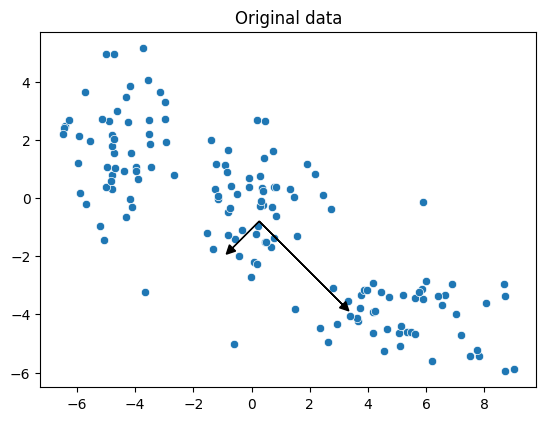

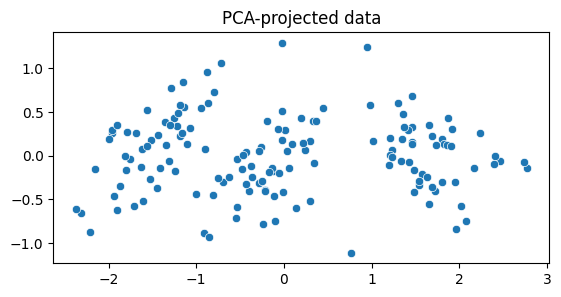

In [11]:
# TODO
import seaborn as sns
import matplotlib.pyplot as plt

# create data
(trainX, trainY) = createData3()

# visualize the data
fig1, ax1 = plt.subplots()
sns.scatterplot(x=trainX[:,0], y=trainX[:,1])
ax1.set_title("Original data")
ax1.set_aspect("equal", adjustable="box")

# standardize data
# ...zero mean and unit variance
[N, p] = trainX.shape
meanMat = np.tile(np.mean(trainX, axis=0), (N, 1))
data = trainX - meanMat
stdDev = (np.tile(np.std(data, axis=0), (N, 1)) + 1e-16)
data = np.divide(data, stdDev)

# do PCA
(eigenvectors, eigenvalues, scores) = pca_svd(data)

# print the PCs
print(f"Principal components: {eigenvectors}")
# ...and add them to the plot
mu = np.mean(trainX, axis=0)
for i in range(2):
    v = eigenvectors[:, i] * 3 * np.sqrt(eigenvalues[i])
    plt.arrow(mu[0], mu[1], v[0], v[1], head_width=0.3, head_length=0.3, color='k')

# plot the data projected onto the first 2 PCs
fig2, ax2 = plt.subplots()
sns.scatterplot(x=scores[:,0], y=scores[:,1])
ax2.set_aspect("equal", adjustable="box")
ax2.set_title("PCA-projected data")

# TODO
Wir erhalten:

Principal components: [[ 0.70710678 -0.70710678] [-0.70710678 -0.70710678]]

*Augabe DR-2*: Bildkompression mit PCA

Wenden Sie die PCA aus Teilaufgabe 2 auf folgendes Grauwertbild an:

    frosch_grau.jpg

Sie können das Bild mit dem Befehl

In [12]:
import matplotlib.image as mpimg

# load image
img = mpimg.imread('frosch_grau.jpg')

laden (bitte ggf. Pfad anpassen).

* Führen Sie eine PCA des Bildes durch, wobei Sie die Spalten als Features und die Zeilen als Samples interpretieren (vgl. Skript).
* Plotten Sie die (nach Varianz sortierten) Eigenwerte, um zu entscheiden, wie viele Principal Components für eine gute Rekonstruktion benötigt werden.
* Führen Sie anschließend eine Rekonstruktion des Bildes mit reduzierter Anzahl an Komponenten durch und dezentralisieren Sie das Ergebnis.
* Beschreiben Sie, wie viel Speicherplatz Sie eingespart haben!

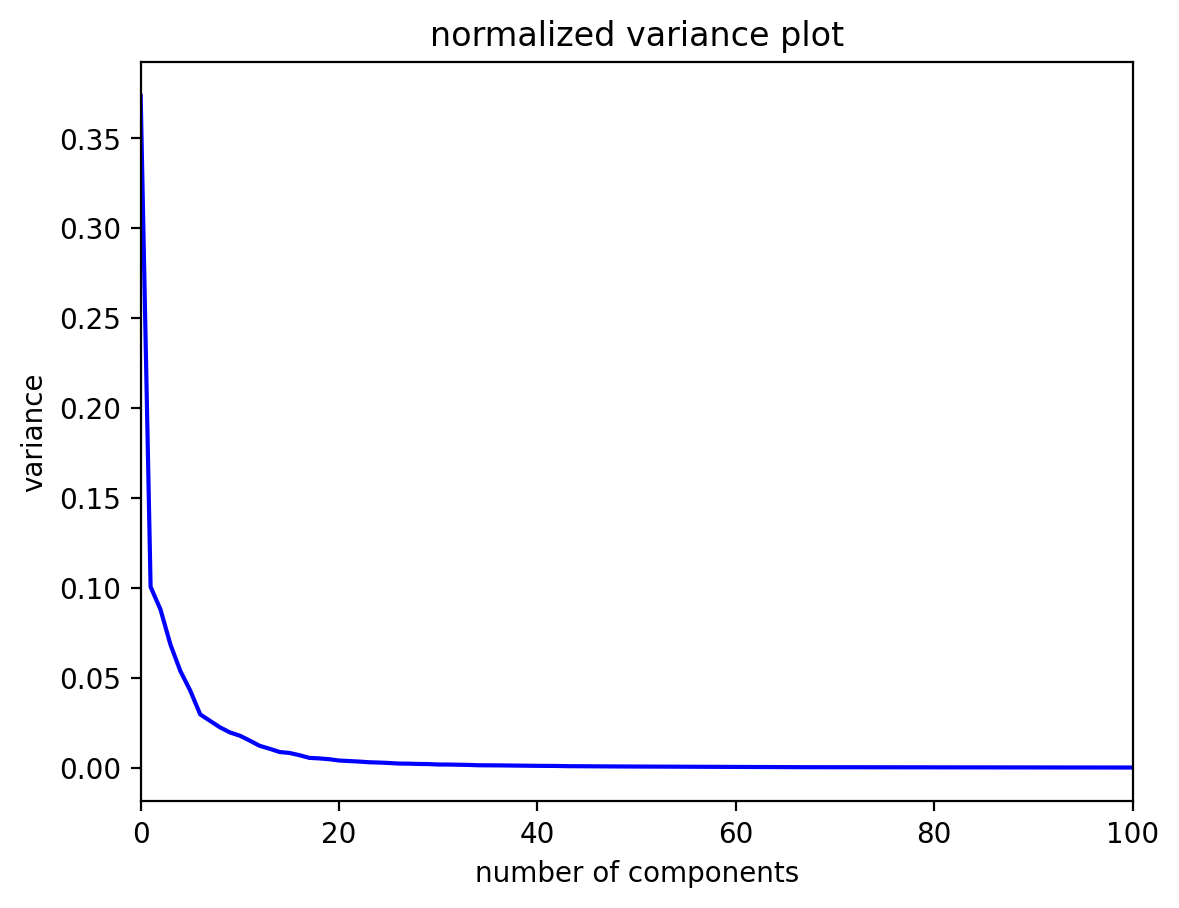

In [26]:
# TODO

# Zunächst laden wir das Bild und führen eine PCA durch,

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.image as mpimg
import numpy as np

# load image
img = mpimg.imread('frosch_grau.jpg')
# ...standardize data
# ...zero mean and unit variance
(N, p) = img.shape
meanMat = np.tile(np.mean(img, axis=0), (N, 1))
data = img - meanMat
stdMat = (np.tile(np.std(img, axis=0), (N, 1)) + 1e-16)
img = np.divide(data, stdMat)

# perform PCA: columns of the image are used as features, rows as samples
[coeff, eigVal, score] = pca_svd(img)

# um anschließend die Varianz zu plotten:

# plot Eigenvalues
eigvals = np.asarray(eigVal)
if eigvals.ndim == 2:
    eigvals = np.diag(eigvals)

plt.plot(np.arange(len(eigvals)), eigvals / eigvals.sum(), '-b')
plt.xlim(0, 100)
plt.title('normalized variance plot')
plt.xlabel('number of components')
plt.ylabel('variance')
plt.show()


Mit 50 Principal Components erhalten wir ein gute Rekonstruktionsergebnis:


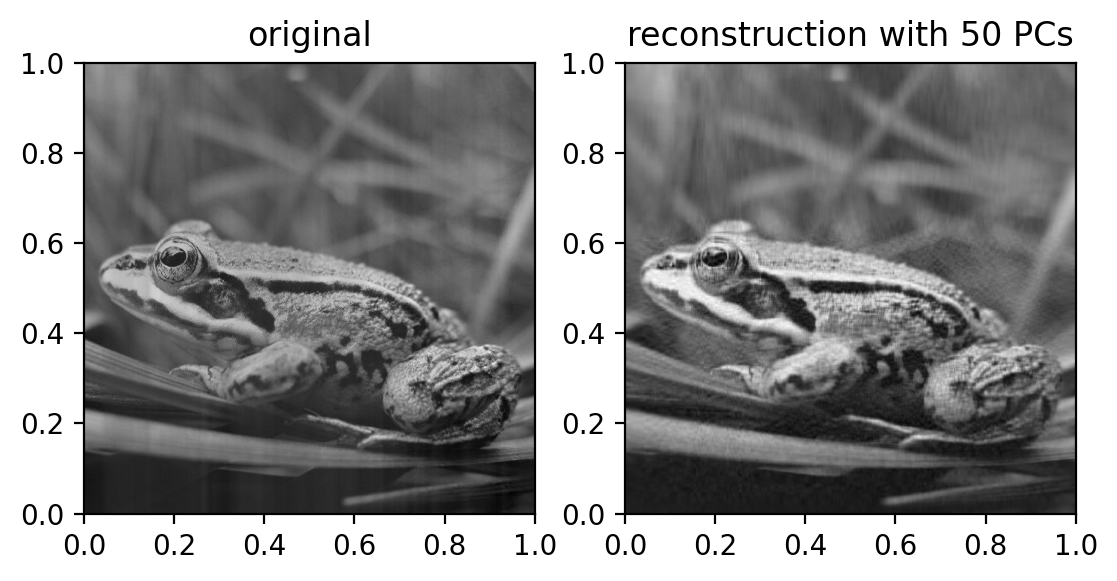

In [29]:
# TODO

# reconstruction
numPCs = 50 # judging from the variance plot, 50 PCs seems reasonable
'''
score contains the p linear factors for each point, coeff
contains the principal components (= p-dimensional basis vectors) in the
columns. Since the linear factors multiply with the basis vectors, coeff
needs to be transposed such that the basis vectors are given by the rows
'''
reconstrImg = np.dot(score[:, 0:numPCs], coeff[:, 0:numPCs].T)
# ...destandardize result, i.e. undo zero-mean-unit-variance scaling
# (necessary because we want to reconstruct the original data)
reconstrImg = np.multiply(reconstrImg, stdMat) + meanMat
# plot images
plt.figure()
# ...original
plt.subplot(1,2,1)
plt.imshow(img, extent=[0, 1, 0, 1], cmap=mpl.colormaps['gray'])
plt.title('original')
#axis equal tight;
# ...reconstructed
plt.subplot(1,2,2)
plt.imshow(reconstrImg, extent=[0, 1, 0, 1], cmap=mpl.colormaps['gray'])
plt.title('reconstruction with ' + str(numPCs) + ' PCs')
plt.show()